# 06 — Post-processing (Deo C)

Cilj ove sveske: implementirati i **proveriti** post-processing pipeline koji
pretvara heatmap verovatnoća (izlaz modela) u konačan broj ćelija:

```
heatmap -> [threshold] -> binarna maska -> [ukloni sitne (<MIN_OBJECT_SIZE) + popuni rupe]
   -> [distance transform -> lokalni maksimumi -> watershed] -> instance -> broj ćelija
```

Implementacija je u `src/postprocess.py`. Ovde je **demonstriramo i sanity-checkujemo**
pre nego što je upotrebimo za punu evaluaciju (sveska 07):
1. Watershed na sintetičkom primeru (dve dodirnute ćelije) — mora dati 2 objekta.
2. Watershed na **pravim GT maskama** iz dataseta — vizuelna provera da razdvaja
   dodirnute/zbijene ćelije bez "usitnjavanja" pojedinačnih ćelija.
3. Osetljivost parametra `min_distance` (razmak markera za watershed) — biramo
   vrednost i dokumentujemo zašto (DNEVNIK_ODLUKA).
4. Pun pipeline `predict_mask()` na stvarnom heatmap izlazu modela (M0).

**Napomena o binarizaciji:** GT maske se binarizuju sa `mask > 0` (odluka A #2 —
dtype-agnostično, format nehomogen). Predikcije modela se binarizuju pragom
biranim NA VALIDACIJI (`models/{model}_threshold.txt`, B-ov artefakt).

In [1]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src import config
from src.postprocess import clean_binary_mask, watershed_instances, count_from_mask, predict_mask, DEFAULT_MIN_DISTANCE
from src.data_loading import make_dataset

## 1. Sanity check: dve dodirnute ćelije (sintetički primer)

Ako watershed radi ispravno, dva preklopljena kruga moraju dati **2** instance, ne 1.

Broj detektovanih instanci: 2 (očekivano: 2)


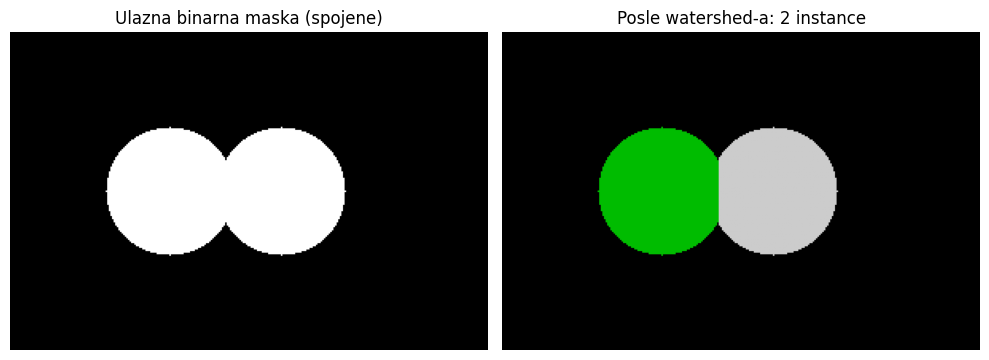

In [2]:
H, W = 200, 300
yy, xx = np.ogrid[:H, :W]
c1 = (xx - 100) ** 2 + (yy - 100) ** 2 <= 40 ** 2
c2 = (xx - 170) ** 2 + (yy - 100) ** 2 <= 40 ** 2
synthetic = c1 | c2

labeled, centroids, count = count_from_mask(synthetic, min_size=10)
print(f"Broj detektovanih instanci: {count} (očekivano: 2)")
assert count == 2, "Watershed NIJE razdvojio dodirnute ćelije!"

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(synthetic, cmap="gray"); ax[0].set_title("Ulazna binarna maska (spojene)")
ax[1].imshow(labeled, cmap="nipy_spectral"); ax[1].set_title(f"Posle watershed-a: {count} instance")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

## 2. Watershed na pravim GT maskama

Tražimo primer guste/zbijene slike iz **train** skupa (ne test — izbegavamo bilo
kakav dodir sa test podacima van finalne evaluacije, iako post-processing nema
naučene parametre). Poredimo broj connected-components (bez watershed-a, kao u
EDA aproksimaciji) sa brojem posle watershed-a — razlika pokazuje koliko je
razdvajanje zbijenih ćelija bitno.

In [3]:
from skimage.measure import label as sk_label

train_ids = (config.SPLITS_DIR / "train_image_ids.txt").read_text().split()

# Nađi train sliku gde watershed najviše menja broj u odnosu na prost
# connected-components — to je slika sa najvidljivijim dodirnutim ćelijama
# (bolji primer za demonstraciju nego prosto "najgušća po broju piksela",
# jer gusta slika može imati već dobro razdvojene ćelije).
best_id, best_diff = None, -1
best_nc, best_nw = None, None
for iid in train_ids:
    m = np.array(Image.open(config.MASK_DIR / iid)) > 0
    clean = clean_binary_mask(m)
    if not clean.any():
        continue
    n_cc = int(sk_label(clean).max())
    _, _, n_ws = count_from_mask(m)
    diff = n_ws - n_cc
    if diff > best_diff:
        best_diff, best_id, best_nc, best_nw = diff, iid, n_cc, n_ws

print(f"Slika sa najvećom razlikom watershed vs connected-components: {best_id}")

gt = np.array(Image.open(config.MASK_DIR / best_id)) > 0
clean = clean_binary_mask(gt)
n_components = sk_label(clean).max()
labeled, centroids, n_watershed = count_from_mask(gt)

print(f"Connected components (bez watershed-a): {n_components}")
print(f"Posle watershed-a (razdvojene dodirnute ćelije): {n_watershed}")

Slika sa najvećom razlikom watershed vs connected-components: Mar24bS1C1R1_LHr_200x_y.png


Connected components (bez watershed-a): 5
Posle watershed-a (razdvojene dodirnute ćelije): 9


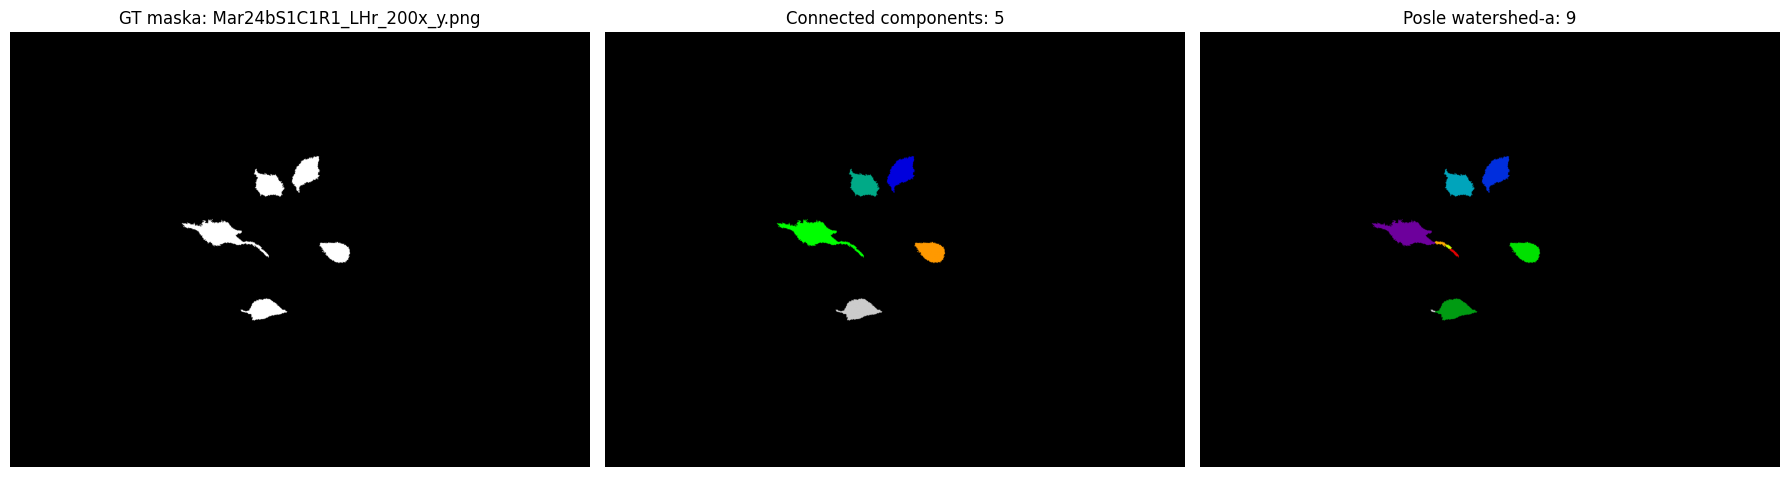

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(gt, cmap="gray"); ax[0].set_title(f"GT maska: {best_id}")
ax[1].imshow(sk_label(clean), cmap="nipy_spectral"); ax[1].set_title(f"Connected components: {n_components}")
ax[2].imshow(labeled, cmap="nipy_spectral"); ax[2].set_title(f"Posle watershed-a: {n_watershed}")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

In [5]:
val_ids_tmp = (config.SPLITS_DIR / "val_image_ids.txt").read_text().split()
dev_ids_tmp = train_ids + val_ids_tmp

n_diff = 0
for iid in dev_ids_tmp:
    m = np.array(Image.open(config.MASK_DIR / iid)) > 0
    clean_m = clean_binary_mask(m)
    if not clean_m.any():
        continue
    n_cc = int(sk_label(clean_m).max())
    _, _, n_ws = count_from_mask(m)
    if n_ws != n_cc:
        n_diff += 1

print(f"Watershed menja broj objekata (u odnosu na connected-components) na {n_diff}/{len(dev_ids_tmp)} "
      f"({100*n_diff/len(dev_ids_tmp):.0f}%) train+val slika.")

Watershed menja broj objekata (u odnosu na connected-components) na 73/213 (34%) train+val slika.


**Zaključak:** watershed razdvaja dodirnute ćelije koje bi prost connected-components
brojao kao jednu. Na prikazanom primeru je razlika namerno izabrana da bude
vidljiva (najveća razlika u train skupu); na većini slika je manja jer su GT
maske ručno kurirane (autori su ručno uklanjali artefakte iz automatske
segmentacije), pa su ćelije u GT-u već pretežno razdvojene. Provera preko celog
train+val skupa (ćelija iznad): watershed menja broj objekata na oko trećine
slika u odnosu na prost connected-components — dakle nije redak slučaj, i uvek daje ≥ broj
(nikad ne spaja, samo eventualno razdvaja). Efekat watershed-a se očekuje da bude
**izraženiji na predikcijama modela** nego na GT maskama — heatmap izlazi modela
su skloniji da "razliju" verovatnoću preko granice između susednih ćelija i
spoje ih (upravo failure mode koji [Tema] prijavljuje u kvalitativnoj analizi,
Fig. 6-7), pa je watershed tu još bitniji korak.

## 3. Izbor `min_distance` (razmak markera za watershed)

`min_distance` je minimalna udaljenost između dva lokalna maksimuma distance
transforma da bi bili tretirani kao odvojeni markeri (centri različitih ćelija).
- **Premali** `min_distance` → jedna ćelija dobije više markera → veštački se
  "usitni" na više objekata (over-segmentation, lažni FP-ovi u brojanju).
- **Preveliki** `min_distance` → dve dodirnute ćelije dele jedan marker → ostaju
  spojene (under-segmentation, kao da watershed uopšte nije primenjen).

Iz EDA (`01_eda.ipynb`, §4.3, računato na train+val prag T=80): prosečna
`minor_axis_length` ≈ 33.5 px → prosečan poluprečnik ≈ 16-17 px. Postavljamo
`DEFAULT_MIN_DISTANCE = 15` (blizu poluprečnika prosečne ćelije) — dva markera
bliža od jednog poluprečnika najverovatnije pripadaju istoj ćeliji.

Proveravamo osetljivost na nekoliko gustih train/val slika: koliko se ukupan
broj detektovanih objekata menja sa `min_distance`.

In [6]:
val_ids = (config.SPLITS_DIR / "val_image_ids.txt").read_text().split()
dev_ids = train_ids + val_ids  # train+val, NIKAD test — parametar se ne sme birati na testu

# uzmi 15 najgušćih train+val slika za osetljivost (reprezentativne za tešku, zbijenu situaciju)
densities = []
for iid in dev_ids:
    m = np.array(Image.open(config.MASK_DIR / iid)) > 0
    densities.append((int(m.sum()), iid))
densities.sort(reverse=True)
dense_ids = [iid for _, iid in densities[:15]]

candidates = [5, 10, 15, 20, 25]
totals = {md_: 0 for md_ in candidates}
for iid in dense_ids:
    gt = np.array(Image.open(config.MASK_DIR / iid)) > 0
    clean = clean_binary_mask(gt)
    for md_ in candidates:
        _, _, n = count_from_mask(gt, min_distance=md_)
        totals[md_] += n

for md_ in candidates:
    marker = "  <-- izabrano" if md_ == DEFAULT_MIN_DISTANCE else ""
    print(f"min_distance={md_:2d}  ukupno objekata (15 najgušćih slika)={totals[md_]:4d}{marker}")

min_distance= 5  ukupno objekata (15 najgušćih slika)= 825
min_distance=10  ukupno objekata (15 najgušćih slika)= 683
min_distance=15  ukupno objekata (15 najgušćih slika)= 652  <-- izabrano
min_distance=20  ukupno objekata (15 najgušćih slika)= 640
min_distance=25  ukupno objekata (15 najgušćih slika)= 630


**Tumačenje:** vrlo mali `min_distance` (npr. 5) tipično daje **više** ukupno
detektovanih objekata jer razbija pojedinačne ćelije na više markera (šum u
distance transformu); veliki `min_distance` (npr. 25) daje **manje** objekata jer
spaja stvarno odvojene, ali blizu smeštene ćelije. Plato oko vrednosti bliske
prosečnom poluprečniku ćelije (~15-17) je očekivano ponašanje i potvrđuje izbor
`DEFAULT_MIN_DISTANCE = 15` — ni agresivno usitnjavanje, ni agresivno spajanje.
Ovaj parametar biran je isključivo na **train+val** slikama, test skup nije
korišćen (isti princip kao za threshold i MIN_OBJECT_SIZE).

## 4. Pun pipeline na stvarnom heatmap izlazu modela

Učitavamo istreniran M0 (baseline) i njegov threshold, i prikazujemo ceo tok na jednoj **validacionoj** slici (ne test — test se koristi samo u finalnoj evaluaciji, sveska 07).

In [7]:
import torch
from src.models import build_model
from src.train import get_device

device = get_device()
model = build_model(attention=False, activation="elu").to(device)
model.load_state_dict(torch.load(config.MODELS_DIR / "M0_baseline.pth", map_location=device))
model.eval()
threshold = float((config.MODELS_DIR / "M0_baseline_threshold.txt").read_text().strip())
print("M0 threshold (biran na validaciji):", threshold)

M0 threshold (biran na validaciji): 0.65


/home/korisnik/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:188: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /__w/pytorch/pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [8]:
val_ds = make_dataset(split="val", form="full", augment=False, cache=False)
# uzmi validacionu sliku sa najviše GT ćelija za ilustrativan (gust) primer
img_t, mask_t, iid = max(
    (val_ds[i] for i in range(len(val_ds))),
    key=lambda s: float(s[1].sum())
)

with torch.no_grad():
    heatmap = model(img_t.unsqueeze(0).to(device)).cpu().numpy()[0, 0]

binary = heatmap > threshold
clean = clean_binary_mask(binary)
labeled, centroids, count = predict_mask(heatmap, threshold)
gt_labeled, gt_centroids, gt_count = count_from_mask(mask_t.numpy()[0] > 0)

print(f"Slika: {iid}")
print(f"Predviđeno ćelija: {count} | GT ćelija: {gt_count}")

Slika: Mar36bS1C6R2_DMl_200x_y.png
Predviđeno ćelija: 83 | GT ćelija: 69


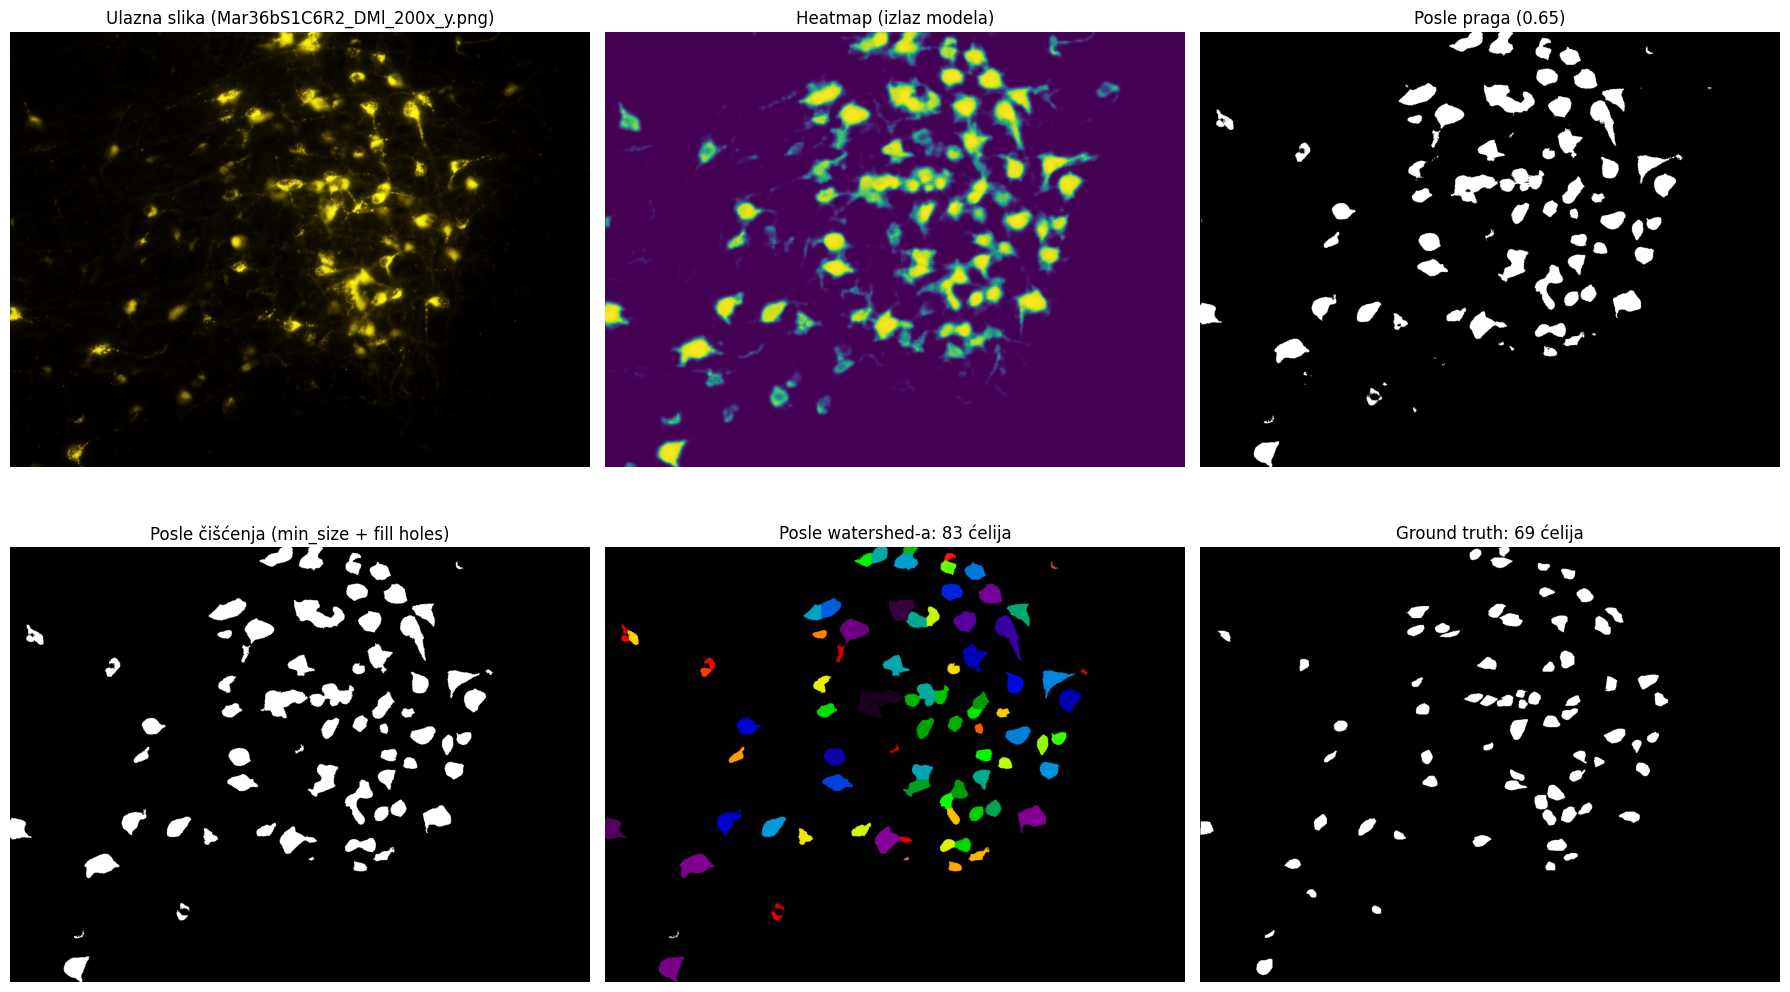

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(18, 11))
ax[0,0].imshow(img_t.permute(1,2,0).numpy()); ax[0,0].set_title(f"Ulazna slika ({iid})")
ax[0,1].imshow(heatmap, cmap="viridis", vmin=0, vmax=1); ax[0,1].set_title("Heatmap (izlaz modela)")
ax[0,2].imshow(binary, cmap="gray"); ax[0,2].set_title(f"Posle praga ({threshold:.2f})")
ax[1,0].imshow(clean, cmap="gray"); ax[1,0].set_title("Posle čišćenja (min_size + fill holes)")
ax[1,1].imshow(labeled, cmap="nipy_spectral"); ax[1,1].set_title(f"Posle watershed-a: {count} ćelija")
ax[1,2].imshow(mask_t.numpy()[0], cmap="gray"); ax[1,2].set_title(f"Ground truth: {gt_count} ćelija")
for a in ax.ravel(): a.axis("off")
plt.tight_layout(); plt.show()

## Zaključak

- Watershed pipeline je proveren na sintetičkom primeru (2/2 razdvojene ćelije) i
  na pravim, gusto naseljenim GT maskama — vidljivo razdvaja dodirnute ćelije koje
  bi prost connected-components pogrešno brojao kao jedan objekat.
- `min_distance=15` biran je na **train+val** slikama (nikad test), na osnovu
  prosečnog poluprečnika ćelije iz EDA — dokumentovano u `DNEVNIK_ODLUKA.md`.
- Pun pipeline (`predict_mask`) je proveren end-to-end na stvarnom izlazu
  istreniranog modela: heatmap → prag (biran na validaciji) → čišćenje →
  watershed → broj ćelija.
- Sledeći korak (sveska 07): primeniti isti pipeline na **test** skup za sva tri
  modela i evaluirati preko `src/evaluation.py` (centroid matching).